En este Notebook en la primera parte se implementó el método de PCA para el conjuto de cancer de mama y el conjunto iris, haciendo cada construcción de manera manual y usando librerias.
En la segunda parte se usó directamete la libreria de from sklearn.decomposition import PCA para calcular los PCA

# Clase 7 
En la clase no.7 no pudimos ejecutar todas las celdas así que ejecutaremos las celdas aquí en la parte de la tarea, además de agregar algunos comentarios propios sobre el código


## 2 Implementación del PCA


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [2]:

cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X = df[cancer['feature_names']]

In [3]:
# Realizamos algunos calculos importantes 
X_mean = X.mean() # Calcula la media de cada columna
X_std = X.std() #Calcula la desviasión estándar de cada columna
Z = (X - X_mean) / X_std 

In [4]:
Z.head(5)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,2.215566,2.253764,...,1.885031,-1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312
1,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,0.001391,-0.867889,...,1.804340,-0.368879,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943
2,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,0.938859,-0.397658,...,1.510541,-0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214
3,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,2.864862,4.906602,...,-0.281217,0.133866,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672
4,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,-0.009552,-0.561956,...,1.297434,-1.465481,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751


In [5]:
Z.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-3.159355e-15,-6.549730e-15,-6.993039e-16,-8.491548e-16,6.093934e-15,-1.111394e-15,-3.121893e-16,1.023981e-15,-1.848160e-15,-1.461046e-15,...,-2.285225e-15,1.735772e-15,-1.223782e-15,6.118909e-16,-5.082441e-15,-2.135374e-15,6.243785e-16,-1.998011e-16,-2.422589e-15,2.510002e-15
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.027864e+00,-2.227289e+00,-1.982759e+00,-1.453164e+00,-3.109349e+00,-1.608721e+00,-1.113893e+00,-1.260710e+00,-2.741705e+00,-1.818265e+00,...,-1.725382e+00,-2.222039e+00,-1.691872e+00,-1.221348e+00,-2.680337e+00,-1.442609e+00,-1.304683e+00,-1.743529e+00,-2.159060e+00,-1.600431e+00
25%,-6.887793e-01,-7.253249e-01,-6.913472e-01,-6.666089e-01,-7.103378e-01,-7.464292e-01,-7.430941e-01,-7.372951e-01,-7.026215e-01,-7.220040e-01,...,-6.743279e-01,-7.479711e-01,-6.889721e-01,-6.415713e-01,-6.906227e-01,-6.804845e-01,-7.558491e-01,-7.557349e-01,-6.412994e-01,-6.913035e-01
50%,-2.148925e-01,-1.045442e-01,-2.357726e-01,-2.949274e-01,-3.486040e-02,-2.217454e-01,-3.419391e-01,-3.973715e-01,-7.156354e-02,-1.781226e-01,...,-2.688030e-01,-4.347738e-02,-2.857288e-01,-3.408813e-01,-4.680159e-02,-2.692639e-01,-2.180402e-01,-2.232725e-01,-1.272975e-01,-2.162538e-01
75%,4.689800e-01,5.836621e-01,4.992377e-01,3.631877e-01,6.356397e-01,4.934227e-01,5.255994e-01,6.463664e-01,5.303125e-01,4.705693e-01,...,5.215568e-01,6.577623e-01,5.398040e-01,3.572747e-01,5.970195e-01,5.391944e-01,5.306742e-01,7.118836e-01,4.497425e-01,4.503661e-01
max,3.967796e+00,4.647799e+00,3.972634e+00,5.245913e+00,4.766717e+00,4.564409e+00,4.239858e+00,3.924477e+00,4.480808e+00,4.906602e+00,...,4.090590e+00,3.882489e+00,4.283568e+00,5.924959e+00,3.951897e+00,5.108382e+00,4.696536e+00,2.683516e+00,6.040726e+00,6.840837e+00


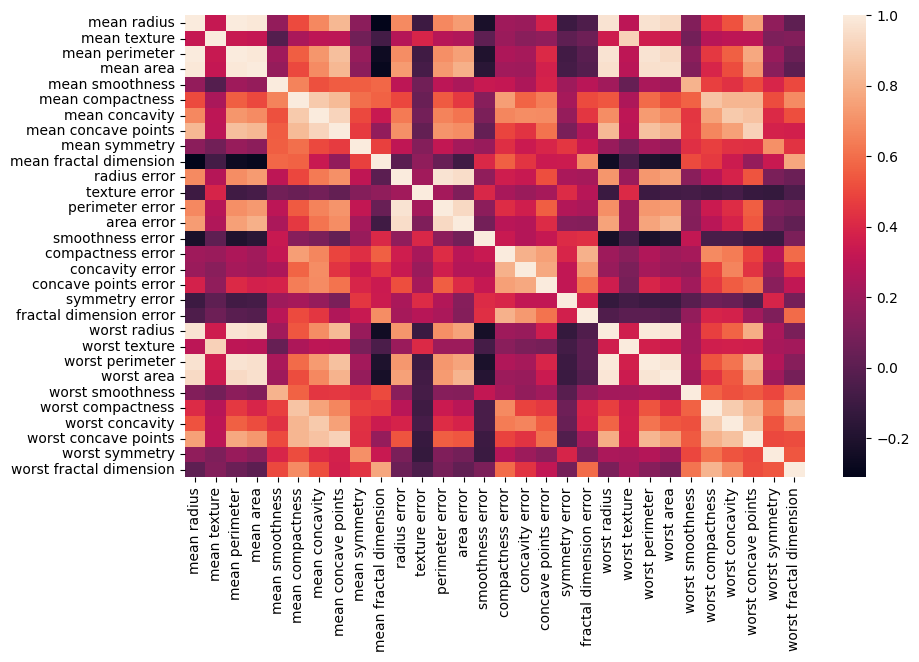

In [6]:
c = Z.cov() # Veamos la correlación entre las variables
plt.figure(figsize=(10, 6))
sns.heatmap(c)
plt.show()

In [7]:
eigenvalues, eigenvectors = np.linalg.eig(c) #Calculamos los valores propios y los vectores propios de la matriz de correlación 
print('Valores propios:\n', eigenvalues)
print('Forma de los valores propios:', eigenvalues.shape)
print('Forma de los vectores propios:', eigenvectors.shape)

Valores propios:
 [1.32816077e+01 5.69135461e+00 2.81794898e+00 1.98064047e+00
 1.64873055e+00 1.20735661e+00 6.75220114e-01 4.76617140e-01
 4.16894812e-01 3.50693457e-01 2.93915696e-01 2.61161370e-01
 2.41357496e-01 1.57009724e-01 9.41349650e-02 7.98628010e-02
 5.93990378e-02 5.26187835e-02 4.94775918e-02 1.33044823e-04
 7.48803097e-04 1.58933787e-03 6.90046388e-03 8.17763986e-03
 1.54812714e-02 1.80550070e-02 2.43408378e-02 2.74394025e-02
 3.11594025e-02 2.99728939e-02]
Forma de los valores propios: (30,)
Forma de los vectores propios: (30, 30)


In [8]:
# Ordenamos los autovalores de mayor a menor 
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

Text(0.5, 1.0, 'Autovalores ordenados')

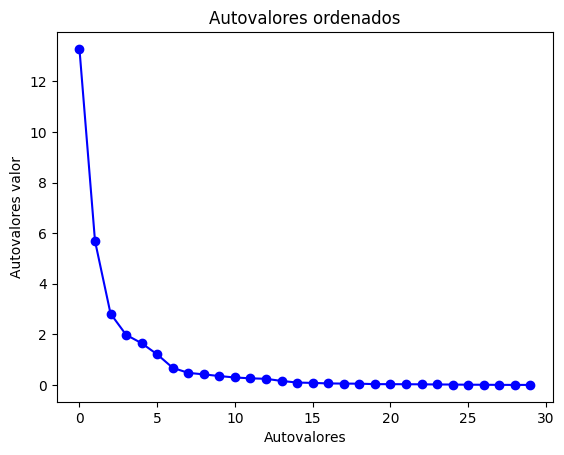

In [9]:
plt.plot(eigenvalues, label = "eigenvalores", marker = "o", color = "blue")
plt.xlabel("Autovalores")
plt.ylabel("Autovalores valor")
plt.title("Autovalores ordenados")

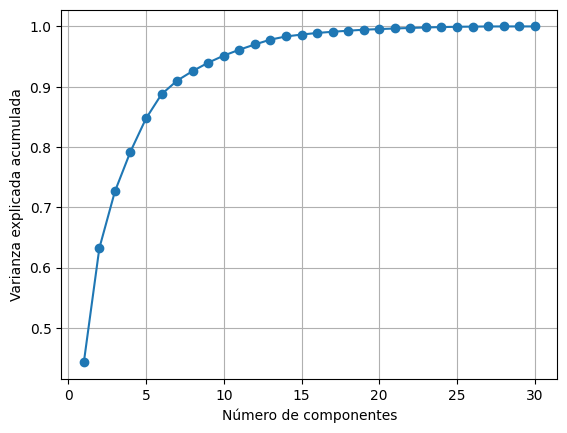

In [10]:
#La varianza explicada es el término que nos da una idea de la cantidad de
#varianza total que ha sido retenida al seleccionar los componentes principales
#en lugar del espacio original de características.

explained_var = np.cumsum(eigenvalues) / np.sum(eigenvalues)
plt.plot(range(1, len(explained_var) + 1), explained_var, marker = "o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid()
plt.show()

In [11]:
explained_var.shape

(30,)

In [12]:
#Ahora vamos a determinar el número de componentes principales. Aquí consideramos una varianza explicada mayor o igual al 50%.
# explained_var >= 0.50 hace algo como [False, False, True, True, ...] 
n_components = np.argmax(explained_var >= 0.50) + 1
n_components

np.int64(2)

In [13]:
u = eigenvectors[:, :n_components]
print(u.shape)

(30, 2)


In [14]:
u[0]

array([ 0.21890244, -0.23385713])

In [15]:
pca_component = pd.DataFrame(u,index = cancer['feature_names'], columns = ['PCA1', 'PCA2'])
pca_component.head(10)

,PCA1,PCA2
mean radius,0.218902,-0.233857
mean texture,0.103725,-0.059706
mean perimeter,0.227537,-0.215181
mean area,0.220995,-0.231077
mean smoothness,0.142590,0.186113
mean compactness,0.239285,0.151892
mean concavity,0.258400,0.060165
mean concave points,0.260854,-0.034768
mean symmetry,0.138167,0.190349
mean fractal dimension,0.064363,0.366575


In [16]:
len(pca_component.index)

30

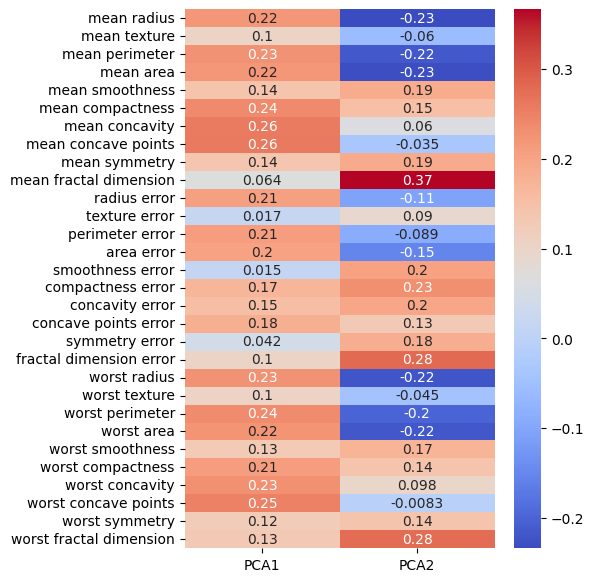

In [17]:
plt.figure(figsize =(5, 7))
sns.heatmap(pca_component, annot=True, cmap='coolwarm')
plt.show()

In [18]:
Z_pca = Z @ pca_component #Realizamos las proyecciones de la matriz Z y nuestros PCA
Z_pca.columns = ['PCA1', 'PCA2']
Z_pca


,PCA1,PCA2
0,9.184755,1.946870
1,2.385703,-3.764859
2,5.728855,-1.074229
3,7.116691,10.266556
4,3.931842,-1.946359
...,...,...
564,6.433655,-3.573673
565,3.790048,-3.580897
566,1.255075,-1.900624
567,10.365673,1.670540


In [19]:
print(Z_pca[['PCA1', 'PCA2']].corr())


              PCA1          PCA2
PCA1  1.000000e+00  4.855143e-16
PCA2  4.855143e-16  1.000000e+00


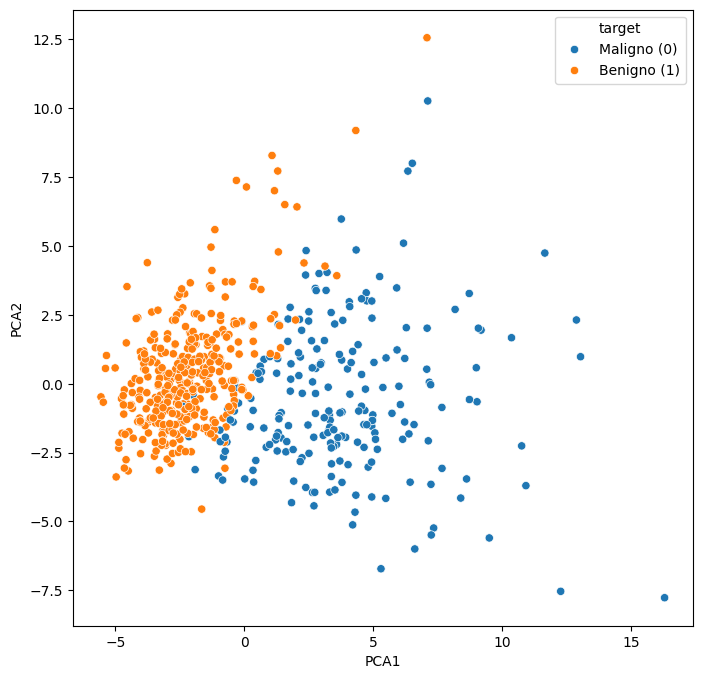

In [20]:
Z_pca['target'] = df['target'].map({0: 'Maligno (0)', 1: 'Benigno (1)'})
plt.figure(figsize=(8,8))
sns.scatterplot(data=Z_pca, x="PCA1", y="PCA2", hue="target")
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()


## Para el conjunto iris

In [21]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

In [22]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

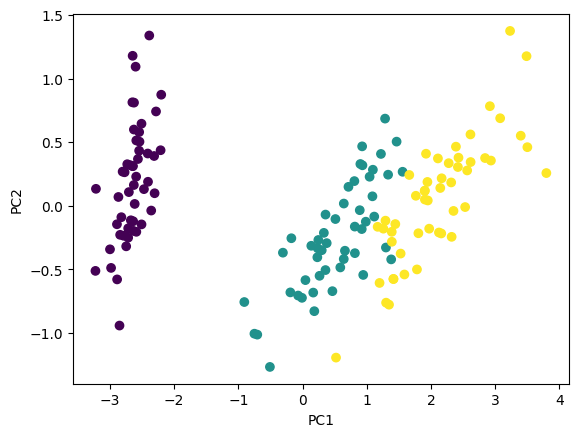

In [23]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [25]:
X_scaled.shape

(150, 4)

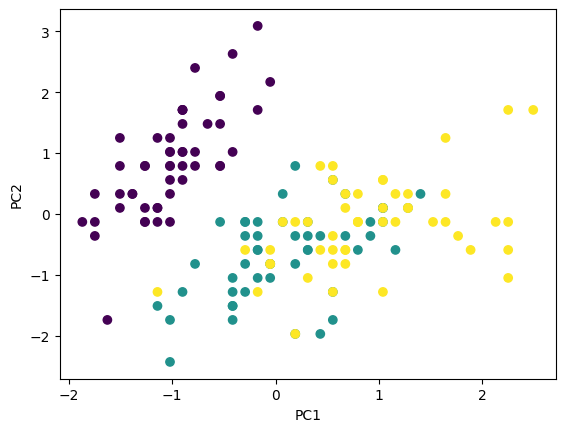

In [26]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Tarea 4 Conjunto de datos de diabetes método de PCA

## 1

In [27]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame=True)
df_diabetes = diabetes.frame
X_diabetes = df_diabetes[diabetes["feature_names"]]
X_diabetes.head(5)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [28]:
scaler = StandardScaler()
X_scaled_diabetes = scaler.fit_transform(X_diabetes)
X_scaled_diabetes

array([[ 0.80050009,  1.06548848,  1.29708846, ..., -0.05449919,
         0.41853093, -0.37098854],
       [-0.03956713, -0.93853666, -1.08218016, ..., -0.83030083,
        -1.43658851, -1.93847913],
       [ 1.79330681,  1.06548848,  0.93453324, ..., -0.05449919,
         0.06015558, -0.54515416],
       ...,
       [ 0.87686984,  1.06548848, -0.33441002, ..., -0.23293356,
        -0.98564884,  0.32567395],
       [-0.9560041 , -0.93853666,  0.82123474, ...,  0.55838411,
         0.93616291, -0.54515416],
       [-0.9560041 , -0.93853666, -1.53537419, ..., -0.83030083,
        -0.08875225,  0.06442552]], shape=(442, 10))

In [29]:
#Veamos que nos puede servir para meter el 80% de la varianza y el numero de componentes 
PCA?


Init signature:
PCA(
    n_components=None,
    *,
    copy=True,
    whiten=False,
    svd_solver='auto',
    tol=0.0,
    iterated_power='auto',
    n_oversamples=10,
    power_iteration_normalizer='auto',
    random_state=None,
)
Docstring:     
Principal component analysis (PCA).

Linear dimensionality reduction using Singular Value Decomposition of the
data to project it to a lower dimensional space. The input data is centered
but not scaled for each feature before applying the SVD.

It uses the LAPACK implementation of the full SVD or a randomized truncated
SVD by the method of Halko et al. 2009, depending on the shape of the input
data and the number of components to extract.

With sparse inputs, the ARPACK implementation of the truncated SVD can be
used (i.e. through :func:`scipy.sparse.linalg.svds`). Alternatively, one
may consider :class:`TruncatedSVD` where the data are not centered.

Notice that this class only supports sparse inputs for some solvers such as
"arpack" and "c

## 2
Notamos que si ponemos n_component = 0.8 nos da directamente la conservación del 80% de la varianza, y los componentes nos lo dara directamente, dándonos 5 componentes 
Estamos usando todo el conjunto para entrenar a nuestro PCA, esto lo vimos después de la clase correspondiente, sería bueno hacer esto, usando el 70-80% de los datos


In [30]:
pca = PCA(n_components=0.8) 
X_pca_diabetes = pca.fit_transform(X_scaled_diabetes)

X_pca_diabetes.shape

(442, 5)

## 3 

In [31]:
#vemos que cosas nos pueden servir para comparar 
X_scaled_diabetes.nbytes?

Type:        int
String form: 35360
Docstring:  
int([x]) -> integer
int(x, base=10) -> integer

Convert a number or string to an integer, or return 0 if no arguments
are given.  If x is a number, return x.__int__().  For floating-point
numbers, this truncates towards zero.

If x is not a number or if base is given, then x must be a string,
bytes, or bytearray instance representing an integer literal in the
given base.  The literal can be preceded by '+' or '-' and be surrounded
by whitespace.  The base defaults to 10.  Valid bases are 0 and 2-36.
Base 0 means to interpret the base from the string as an integer literal.
>>> int('0b100', base=0)
4

In [32]:
original_kb = X_scaled_diabetes.nbytes / 1024
reduced_kb = X_pca_diabetes.nbytes / 1024

print("Original:", original_kb, "KB")
print("Reducido:", reduced_kb, "KB")

Original: 34.53125 KB
Reducido: 17.265625 KB


## 4 
Proyectamos los datos estandarizados al espacio reducido y luego reconstruimos una aproximacón de los datos originales

In [33]:
X_reduced_diabetes = pca.transform(X_scaled_diabetes)
X_reconstructed = pca.inverse_transform(X_reduced_diabetes)


## 5
Calculamos el error de reconstrucción

In [34]:
from sklearn.metrics import mean_squared_error


Veamos que podemos utlizar 
En este caso, notamos que debemos de darle dos variables de entrada, una nuestros valores escalados y la otra nuestros valores reconstruidos

In [35]:
mean_squared_error?

Signature:
mean_squared_error(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average',
)
Docstring:
Mean squared error regression loss.

Read more in the :ref:`User Guide <mean_squared_error>`.

Parameters
----------
y_true : array-like of shape (n_samples,) or (n_samples, n_outputs)
    Ground truth (correct) target values.

y_pred : array-like of shape (n_samples,) or (n_samples, n_outputs)
    Estimated target values.

sample_weight : array-like of shape (n_samples,), default=None
    Sample weights.

multioutput : {'raw_values', 'uniform_average'} or array-like of shape             (n_outputs,), default='uniform_average'
    Defines aggregating of multiple output values.
    Array-like value defines weights used to average errors.

    'raw_values' :
        Returns a full set of errors in case of multioutput input.

    'uniform_average' :
        Errors of all outputs are averaged with uniform weight.

Returns
-------
loss : float or array of flo

In [36]:
mse = mean_squared_error(X_scaled_diabetes, X_reconstructed)

print("MSE:", mse)

MSE: 0.16598455185932298


## 6 Gráficas
Aquí hacemos un for, usando todo lo que tenemos, y nos damos cuenta que para N = 8, el error deja de ser insignificativo

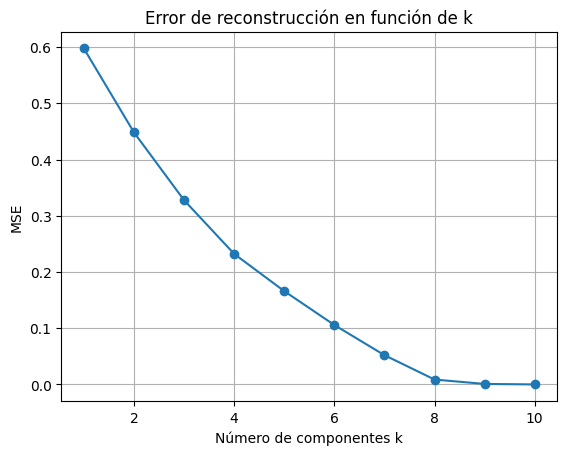

In [37]:
mse_values = []
N = 10
for k in range(1, N+1):

    pca_k = PCA(n_components=k)

    X_reduced_k = pca_k.fit_transform(X_scaled_diabetes)

    X_reconstructed_k = pca_k.inverse_transform(X_reduced_k)

    mse_k = mean_squared_error(X_scaled_diabetes, X_reconstructed_k)

    mse_values.append(mse_k)

plt.plot(range(1, N+1), mse_values, marker='o')

plt.xlabel("Número de componentes k")
plt.ylabel("MSE")
plt.title("Error de reconstrucción en función de k")
plt.grid()

plt.show()